In this exercise, we will introduce SimpleITK. SimpleITK is an open-source image analysis toolkit designed to provide a simple and efficient way to access and manipulate 3D image data. It is a simplified, user-friendly interface to the Insight Segmentation and Registration Toolkit (ITK), a widely used image analysis library for image processing. SimpleITK is written in C++, but provides bindings for several programming languages, including Python. You can find more information about SimpleITK

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk
from IPython.display import clear_output
from skimage.util import img_as_ubyte

In [3]:
def imshow_orthogonal_view(sitkImage, origin=None, title=None):
    """
    Display the orthogonal views of a 3D volume from the middle of the volume.

    Parameters
    ----------
    sitkImage : SimpleITK image
        Image to display.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left
    """
    data = sitk.GetArrayFromImage(sitkImage)

    if origin is None:
        origin = np.array(data.shape) // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    data = img_as_ubyte(data / np.max(data))
    axes[0].imshow(data[origin[0], ::-1, ::-1], cmap="gray")
    axes[0].set_title("Axial")

    axes[1].imshow(data[::-1, origin[1], ::-1], cmap="gray")
    axes[1].set_title("Coronal")

    axes[2].imshow(data[::-1, ::-1, origin[2]], cmap="gray")
    axes[2].set_title("Sagittal")

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)


def overlay_slices(sitkImage0, sitkImage1, origin=None, title=None):
    """
    Overlay the orthogonal views of a two 3D volume from the middle of the volume.
    The two volumes must have the same shape. The first volume is displayed in red,
    the second in green.

    Parameters
    ----------
    sitkImage0 : SimpleITK image
        Image to display in red.
    sitkImage1 : SimpleITK image
        Image to display in green.
    origin : array_like, optional
        Origin of the orthogonal views, represented by a point [x,y,z].
        If None, the middle of the volume is used.
    title : str, optional
        Super title of the figure.

    Note:
    On the axial and coronal views, patient's left is on the right
    On the sagittal view, patient's anterior is on the left
    """
    vol0 = sitk.GetArrayFromImage(sitkImage0)
    vol1 = sitk.GetArrayFromImage(sitkImage1)

    if vol0.shape != vol1.shape:
        raise ValueError("The two volumes must have the same shape.")
    if (
        np.min(vol0) < 0 or np.min(vol1) < 0
    ):  # Remove negative values - Relevant for the noisy images
        vol0[vol0 < 0] = 0
        vol1[vol1 < 0] = 0
    if origin is None:
        origin = np.array(vol0.shape) // 2

    sh = vol0.shape
    R = img_as_ubyte(vol0 / np.max(vol0))
    G = img_as_ubyte(vol1 / np.max(vol1))

    vol_rgb = np.zeros(shape=(sh[0], sh[1], sh[2], 3), dtype=np.uint8)
    vol_rgb[:, :, :, 0] = R
    vol_rgb[:, :, :, 1] = G

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(vol_rgb[origin[0], ::-1, ::-1, :])
    axes[0].set_title("Axial")

    axes[1].imshow(vol_rgb[::-1, origin[1], ::-1, :])
    axes[1].set_title("Coronal")

    axes[2].imshow(vol_rgb[::-1, ::-1, origin[2], :])
    axes[2].set_title("Sagittal")

    [ax.set_axis_off() for ax in axes]

    if title is not None:
        fig.suptitle(title, fontsize=16)

In [4]:
def composite2affine(composite_transform, result_center=None):
    """
    Combine all of the composite transformation's contents to form an equivalent affine transformation.
    Args:
        composite_transform (SimpleITK.CompositeTransform): Input composite transform which contains only
                                                            global transformations, possibly nested.
        result_center (tuple,list): The desired center parameter for the resulting affine transformation.
                                    If None, then set to [0,...]. This can be any arbitrary value, as it is
                                    possible to change the transform center without changing the transformation
                                    effect.
    Returns:
        SimpleITK.AffineTransform: Affine transformation that has the same effect as the input composite_transform.

    Source:
        https://github.com/InsightSoftwareConsortium/SimpleITK-Notebooks/blob/master/Python/22_Transforms.ipynb
    """
    # Flatten the copy of the composite transform, so no nested composites.
    flattened_composite_transform = sitk.CompositeTransform(composite_transform)
    flattened_composite_transform.FlattenTransform()
    tx_dim = flattened_composite_transform.GetDimension()
    A = np.eye(tx_dim)
    c = np.zeros(tx_dim) if result_center is None else result_center
    t = np.zeros(tx_dim)
    for i in range(flattened_composite_transform.GetNumberOfTransforms() - 1, -1, -1):
        curr_tx = flattened_composite_transform.GetNthTransform(i).Downcast()
        # The TranslationTransform interface is different from other
        # global transformations.
        if curr_tx.GetTransformEnum() == sitk.sitkTranslation:
            A_curr = np.eye(tx_dim)
            t_curr = np.asarray(curr_tx.GetOffset())
            c_curr = np.zeros(tx_dim)
        else:
            A_curr = np.asarray(curr_tx.GetMatrix()).reshape(tx_dim, tx_dim)
            c_curr = np.asarray(curr_tx.GetCenter())
            # Some global transformations do not have a translation
            # (e.g. ScaleTransform, VersorTransform)
            get_translation = getattr(curr_tx, "GetTranslation", None)
            if get_translation is not None:
                t_curr = np.asarray(get_translation())
            else:
                t_curr = np.zeros(tx_dim)
        A = np.dot(A_curr, A)
        t = np.dot(A_curr, t + c - c_curr) + t_curr + c_curr - c

    return sitk.AffineTransform(A.flatten(), t, c)

In [5]:
# Callback invoked when the StartEvent happens, sets up our new data.
def start_plot():
    global metric_values, multires_iterations

    metric_values = []
    multires_iterations = []


# Callback invoked when the EndEvent happens, do cleanup of data and figure.
def end_plot():
    global metric_values, multires_iterations

    del metric_values
    del multires_iterations
    # Close figure, we don't want to get a duplicate of the plot latter on.
    plt.close()


# Callback invoked when the IterationEvent happens, update our data and display new figure.
def plot_values(registration_method):
    global metric_values, multires_iterations

    metric_values.append(registration_method.GetMetricValue())
    # Clear the output area (wait=True, to reduce flickering), and plot current data
    clear_output(wait=True)
    # Plot the similarity metric values
    plt.plot(metric_values, "r")
    plt.plot(
        multires_iterations,
        [metric_values[index] for index in multires_iterations],
        "b*",
    )
    plt.xlabel("Iteration Number", fontsize=12)
    plt.ylabel("Metric Value", fontsize=12)
    plt.show()


# Callback invoked when the sitkMultiResolutionIterationEvent happens, update the index into the
# metric_values list.
def update_multires_iterations():
    global metric_values, multires_iterations
    multires_iterations.append(len(metric_values))


def command_iteration(method):
    print(
        f"{method.GetOptimizerIteration():3} "
        + f"= {method.GetMetricValue():10.5f} "
        + f": {method.GetOptimizerPosition()}"
    )

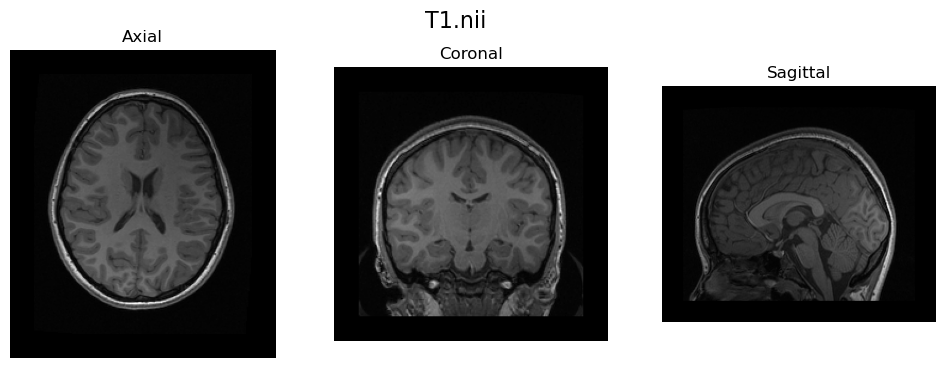

In [6]:
dir_in = "data/"
vol_sitk = sitk.ReadImage(dir_in + "ImgT1.nii")

# Display the volume
imshow_orthogonal_view(vol_sitk, title="T1.nii")

What is an Affine Transformation?
A transformation that can be expressed in the form of a matrix multiplication (linear transformation) followed by a vector addition (translation).
https://docs.opencv.org/4.x/d4/d61/tutorial_warp_affine.html

https://math.stackexchange.com/questions/3242495/yaw-pitch-and-roll-composition

In [13]:
def rotation_matrix(pitch: float, roll: float, yaw: float):
    """
    Returns a 4x4 affine matrix for a given roll, pitch and yaw
    Args:
       pitch (float): pitch of rotation in radians
       roll (float): roll of rotation in radians
       yaw (float): yaw of rotation in radians
    Returns:
        4x4 affine matrix
    """
    # Assume FRD position
    Rx = np.asarray(
        [
            [1, 0, 0, 0],
            [0, np.cos(pitch), -np.sin(pitch), 0],
            [0, np.sin(pitch), np.cos(pitch), 0],
            [0, 0, 0, 1],
        ]
    )
    Ry = np.asarray(
        [
            [np.cos(roll), 0, np.sin(roll), 0],
            [0, 1, 0, 0],
            [-np.sin(roll), 0, np.cos(roll), 0],
            [0, 0, 0, 1]
        ]
    )
    Rz = np.asarray(
        [
            [np.cos(yaw), -np.sin(yaw), 0, 0],
            [np.sin(yaw), np.cos(yaw), 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ]
    )
    return Rx @ Ry @ Rz

In [16]:
pitch_degrees = 25
pitch_radians = 25 * np.pi / 180.0
assert pitch_radians == np.deg2rad(pitch_degrees)
rotation_matrix(pitch_radians, 0, 0)

array([[ 1.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.90630779, -0.42261826,  0.        ],
       [ 0.        ,  0.42261826,  0.90630779,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

The terms "moving" and "fixed" reflect their roles in the registration process:
The fixed image defines the target coordinate system or reference frame.
The moving image is the one that undergoes transformation to align with the fixed image.

An important consideration it is that ITK transforms store the resampling transform/backward mapping transform (fixed to moving image). And then, internally, it applies the inverse of the transform to the moving image.
This means that we have to pass the inverse matrix of the one we have defined. This is because the transformation is applied to the moving image and not to the fixed image. It is important to consider when we want to apply the transformation to the fixed image.

Basically transform is applied from moving to fixed, and our transform we gave is from fixed to moving. Therefore we need to care about its inverse


In [19]:
# Define the roll rotation in radians
angle = 25  # degrees
pitch_radians = np.deg2rad(angle)

# Create the Affine transform and set the rotation
transform = sitk.AffineTransform(3)

centre_image = np.array(vol_sitk.GetSize()) / 2 - 0.5  # Image Coordinate System
centre_world = vol_sitk.TransformContinuousIndexToPhysicalPoint(
    centre_image
)  # World Coordinate System
rot_matrix = rotation_matrix(pitch_radians, 0, 0)[
    :3, :3
]  # SimpleITK inputs the rotation and the translation separately

transform.SetCenter(centre_world)  # Set the rotation centre
# Note that inverse is its transpose
transform.SetMatrix(rot_matrix.T.flatten())

# Apply the transformation to the image
ImgT1_A = sitk.Resample(vol_sitk, transform)

# Save the rotated image
sitk.WriteImage(ImgT1_A, dir_in + "ImgT1_A.nii")

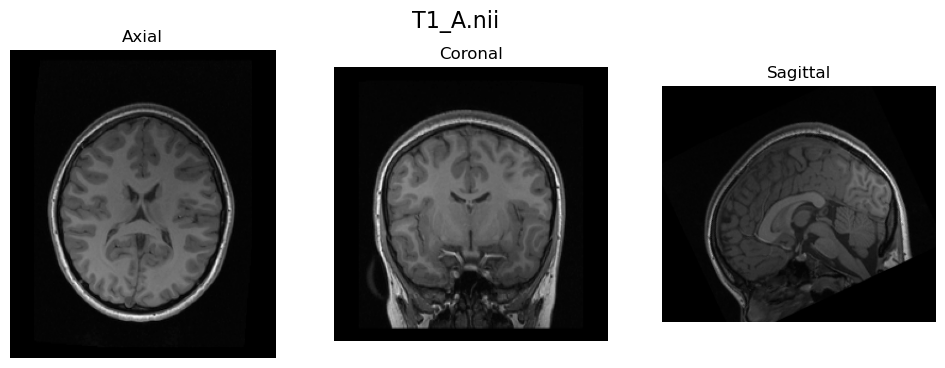

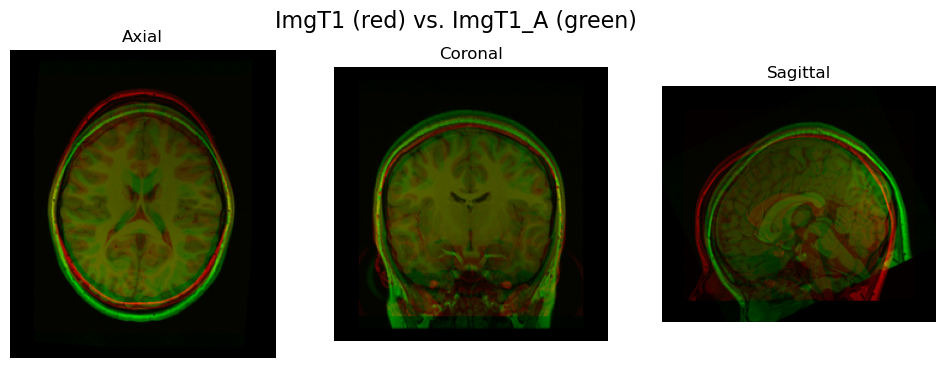

In [20]:
imshow_orthogonal_view(ImgT1_A, title="T1_A.nii")
overlay_slices(vol_sitk, ImgT1_A, title="ImgT1 (red) vs. ImgT1_A (green)")

## Registration of a moving image to a fixed image

In [21]:
dir_in = "data/"
fixed_image = sitk.ReadImage(dir_in + "ImgT1.nii")
moving_image = sitk.ReadImage(dir_in + "ImgT1_A.nii")

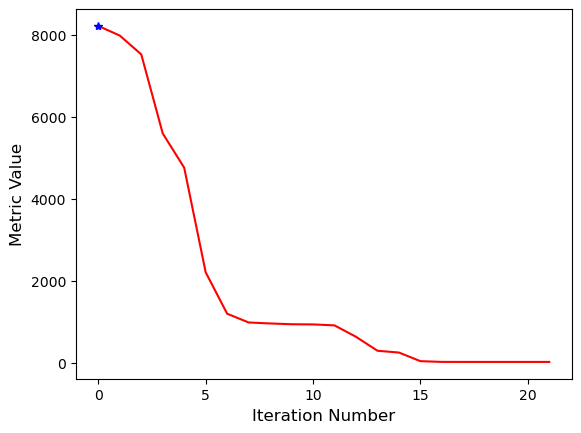

In [22]:
# Set the registration - Fig. 1 from the Theory Note
R = sitk.ImageRegistrationMethod()

# Set a one-level the pyramid scheule. [Pyramid step]
R.SetShrinkFactorsPerLevel(shrinkFactors=[2])
R.SetSmoothingSigmasPerLevel(smoothingSigmas=[0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

# Set the interpolator [Interpolation step]
R.SetInterpolator(sitk.sitkLinear)

# Set the similarity metric [Metric step]
R.SetMetricAsMeanSquares()

# Set the sampling strategy [Sampling step]
R.SetMetricSamplingStrategy(R.RANDOM)
R.SetMetricSamplingPercentage(0.50)

# Set the optimizer [Optimization step]
R.SetOptimizerAsPowell(stepLength=0.1, numberOfIterations=25)

# Initialize the transformation type to rigid
initTransform = sitk.Euler3DTransform()
R.SetInitialTransform(initTransform, inPlace=False)

# Some extra functions to keep track to the optimization process
# R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(R)) # Print the iteration number and metric value
R.AddCommand(
    sitk.sitkStartEvent, start_plot
)  # Plot the similarity metric values across iterations
R.AddCommand(sitk.sitkEndEvent, end_plot)
R.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
R.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(R))

# Estimate the registration transformation [metric, optimizer, transform]
tform_reg = R.Execute(fixed_image, moving_image)

# Apply the estimated transformation to the moving image
ImgT1_B = sitk.Resample(moving_image, tform_reg)

# Save
sitk.WriteImage(ImgT1_B, dir_in + "ImgT1_B.nii")

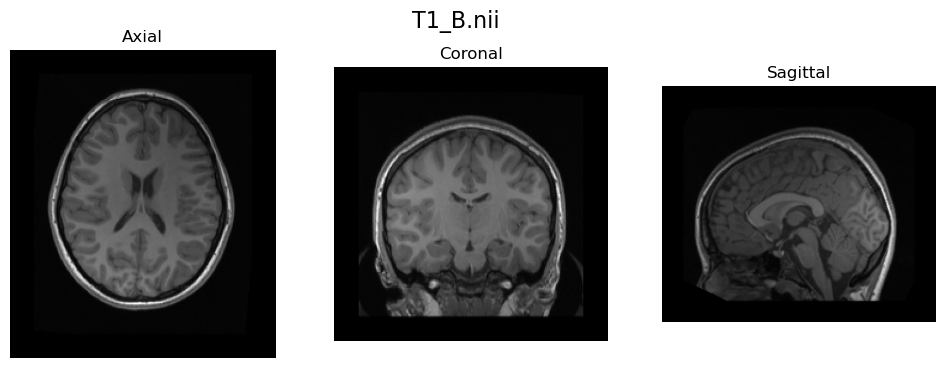

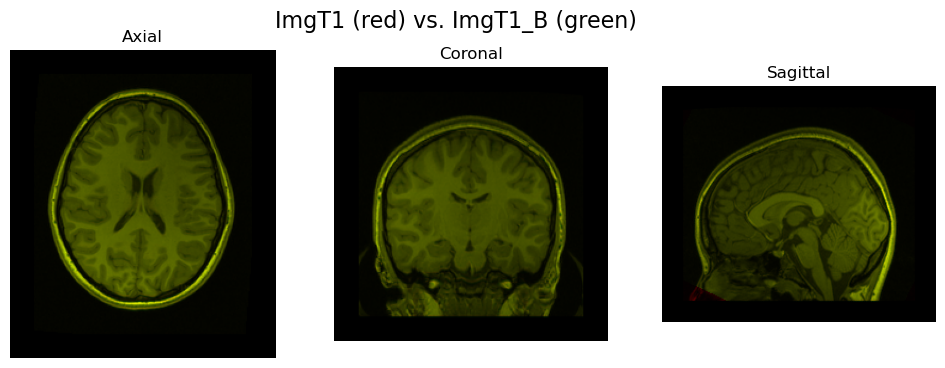

In [27]:
imshow_orthogonal_view(ImgT1_B, title="T1_B.nii")
overlay_slices(fixed_image, ImgT1_B, title="ImgT1 (red) vs. ImgT1_B (green)")

In [35]:
estimated_tform = tform_reg.GetNthTransform(0).GetMatrix()  # Transform matrix
estimated_translation = tform_reg.GetNthTransform(0).GetTranslation()  # Translation vector
params = tform_reg.GetParameters()  # Parameters (Rx, Ry, Rz, Tx, Ty, Tz)
params

(0.43628188701777343,
 -2.706853112465828e-06,
 1.323867385923702e-05,
 -0.0013181877372966805,
 11.167924189043614,
 30.626212563388705)

In [38]:
def homogeneous_matrix_from_transform(transform):
    """Convert a SimpleITK transform to a homogeneous matrix."""
    matrix = np.zeros((4, 4))
    matrix[:3, :3] = np.reshape(np.array(transform.GetMatrix()), (3, 3))
    matrix[:3, 3] = transform.GetTranslation()
    matrix[3, 3] = 1
    return matrix


matrix_estimated = homogeneous_matrix_from_transform(tform_reg.GetNthTransform(0))
matrix_applied = homogeneous_matrix_from_transform(transform)
matrix_estimated, matrix_applied

(array([[ 1.00000000e+00, -1.19985953e-05,  2.88744719e-06,
         -1.31818774e-03],
        [ 1.20948320e-05,  9.06329097e-01, -4.22572560e-01,
          1.11679242e+01],
        [ 2.45329974e-06,  4.22572560e-01,  9.06329097e-01,
          3.06262126e+01],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          1.00000000e+00]]),
 array([[ 1.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.90630779,  0.42261826,  0.        ],
        [ 0.        , -0.42261826,  0.90630779,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  1.        ]]))

In [37]:
tform_reg.WriteTransform(dir_in + "A1.tfm")
tform_loaded = sitk.ReadTransform(dir_in + "A1.tfm")

### Change centre of rotation

In [39]:
initTransform = sitk.CenteredTransformInitializer(
    fixed_image,
    moving_image,
    sitk.Euler3DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY,
)

Make four rotation matrices that rotate the ImgT1nii in steps of 60 degrees starting from 60 degrees. Apply the rotation to ImgT1.nii, reslice and store the resulting images as ImgT1_60.nii, ImgT1_120.nii etc. Show in ortho-view that the rotations are applied as expected for each new image.

In [41]:
#rotate 4 times in yaw
angles = [60, 120, 180, 240, 300]
for angle in angles:
    # Define the roll rotation in radians
    yaw_radians = np.deg2rad(angle)

    # Create the Affine transform and set the rotation
    transform = sitk.AffineTransform(3)

    centre_image = np.array(vol_sitk.GetSize()) / 2 - 0.5  # Image Coordinate System
    centre_world = vol_sitk.TransformContinuousIndexToPhysicalPoint(
        centre_image
    )  # World Coordinate System
    rot_matrix = rotation_matrix(0, 0, yaw_radians)[
        :3, :3
    ]  # SimpleITK inputs the rotation and the translation separately

    transform.SetCenter(centre_world)  # Set the rotation centre
    # Note that inverse is its transpose
    transform.SetMatrix(rot_matrix.T.flatten())

    # Apply the transformation to the image
    ImgT1_A = sitk.Resample(vol_sitk, transform)
    image_name = f"ImgT1_{angle}.nii"
    # Save the rotated image
    sitk.WriteImage(ImgT1_A, dir_in + image_name)

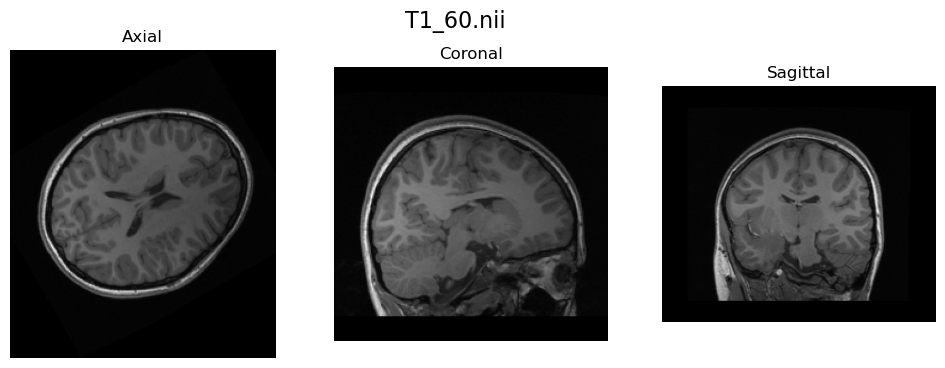

In [45]:
dir_in = "data/"
vol_sitk = sitk.ReadImage(dir_in + "ImgT1_60.nii")
imshow_orthogonal_view(vol_sitk, title="T1_60.nii")

Use ImgT1_120.nii as the fixed image, and the other three rotated images from Exercise 8 as the moving images. Run the registration to find the affine matrix and include the reslicing procedure for each of the moving images. Show in ortho-view the resliced images and describe what the rotation angles are. Save the transforms with the name "Ex9_60.tfm, Ex10_180.tfm, Ex10_240.tfm" Do the rotations agree with those in Exercise 8?

In [50]:
fixed_image = sitk.ReadImage(dir_in + "ImgT1_120.nii")
moving_image1 = (sitk.ReadImage(dir_in + "ImgT1_60.nii"), 60)
moving_image2 = (sitk.ReadImage(dir_in + "ImgT1_180.nii"), 180)
moving_image3 = (sitk.ReadImage(dir_in + "ImgT1_240.nii"), 240)
moving_image4 = (sitk.ReadImage(dir_in + "ImgT1_300.nii"), 300)
moving_stuffs = [moving_image1, moving_image2, moving_image3, moving_image4]

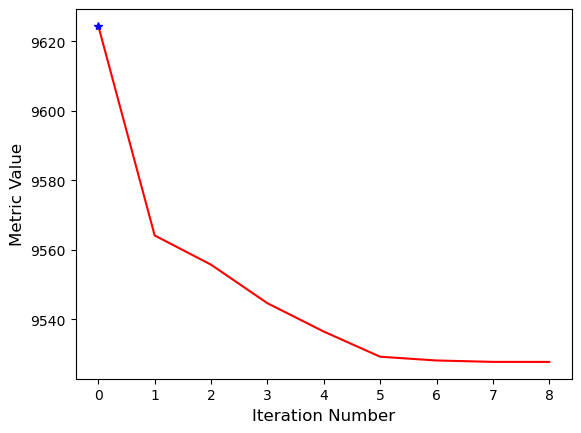

In [52]:
for moving_stuff in moving_stuffs:
    moving_image = moving_stuff[0]
    angle = moving_stuff[1]    
    # Set the registration - Fig. 1 from the Theory Note
    R = sitk.ImageRegistrationMethod()

    # Set a one-level the pyramid scheule. [Pyramid step]
    R.SetShrinkFactorsPerLevel(shrinkFactors=[2])
    R.SetSmoothingSigmasPerLevel(smoothingSigmas=[0])
    R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

    # Set the interpolator [Interpolation step]
    R.SetInterpolator(sitk.sitkLinear)

    # Set the similarity metric [Metric step]
    R.SetMetricAsMeanSquares()

    # Set the sampling strategy [Sampling step]
    R.SetMetricSamplingStrategy(R.RANDOM)
    R.SetMetricSamplingPercentage(0.50)

    # Set the optimizer [Optimization step]
    R.SetOptimizerAsPowell(stepLength=0.5, numberOfIterations=25)

    # Initialize the transformation type to rigid
    initTransform = sitk.Euler3DTransform()
    R.SetInitialTransform(initTransform, inPlace=False)

    # Some extra functions to keep track to the optimization process
    # R.AddCommand(sitk.sitkIterationEvent, lambda: command_iteration(R)) # Print the iteration number and metric value
    R.AddCommand(
        sitk.sitkStartEvent, start_plot
    )  # Plot the similarity metric values across iterations
    R.AddCommand(sitk.sitkEndEvent, end_plot)
    R.AddCommand(sitk.sitkMultiResolutionIterationEvent, update_multires_iterations)
    R.AddCommand(sitk.sitkIterationEvent, lambda: plot_values(R))

    # Estimate the registration transformation [metric, optimizer, transform]
    tform_reg = R.Execute(fixed_image, moving_image)
    tform_reg.WriteTransform(dir_in + f"Ex10_{angle}.tfm")

    # Apply the estimated transformation to the moving image
    ImgT1_B = sitk.Resample(moving_image, tform_reg)

    # Save
    sitk.WriteImage(ImgT1_B, dir_in + f"ImgT1_registration_{angle}.nii")

## Combine a series of affine matches
Often, we wish to combine affine matrixes from a series of images with different registration but apply reslicing only once. The reason is that every time applying reslicing it introduces blurring, and if the image is registered and resliced at each step in a series of rotations, the final image will become very affected by blurring. This we can avoid by first finding the transformation matrix per registration step, then combining them into one matrix, and then applying the reslicing as the final step to the combined affine transformation.


In [56]:
# Load the transforms from file
tform_60 = sitk.ReadTransform("data/Ex10_60.tfm")
tform_180 = sitk.ReadTransform("data/Ex10_180.tfm")
tform_240 = sitk.ReadTransform("data/Ex10_240.tfm")
tform_300 = sitk.ReadTransform("data/Ex10_300.tfm")

# Option A: Combine the transforms using the sitk.CompositeTransform(3) function
# Concatenate - The last added transform is applied first
tform_composite = sitk.CompositeTransform(3)

tform_composite.AddTransform(tform_300.GetNthTransform(0))
tform_composite.AddTransform(tform_240.GetNthTransform(0))
tform_composite.AddTransform(tform_180.GetNthTransform(0))
tform_composite.AddTransform(tform_60.GetNthTransform(0))
# Transform the composite transform to an affine transform
affine_composite = composite2affine(tform_composite, centre_world)


In [57]:
# Option B: Combine the transforms manually through multiplication of the homogeneous matrices
A = np.eye(4)
for i in range(tform_composite.GetNumberOfTransforms() - 1, -1, -1):
    tform = tform_composite.GetNthTransform(i)
    A_curr = homogeneous_matrix_from_transform(tform)
    A = np.dot(A_curr, A)

tform = sitk.Euler3DTransform()
tform.SetMatrix(A[:3, :3].flatten())
tform.SetTranslation(A[:3, 3])
tform.SetCenter(centre_world)

In [61]:
fixed_image = sitk.ReadImage(dir_in + "ImgT1_300.nii")
moving_image = sitk.ReadImage(dir_in + "ImgT1_60.nii")

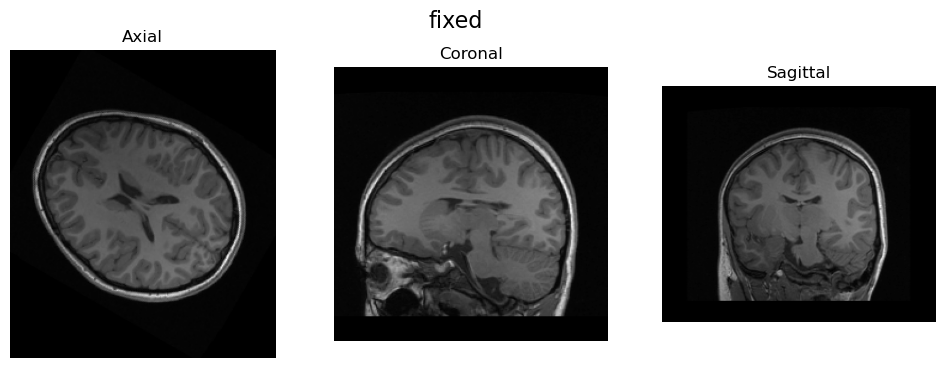

In [62]:
imshow_orthogonal_view(fixed_image, title="fixed")

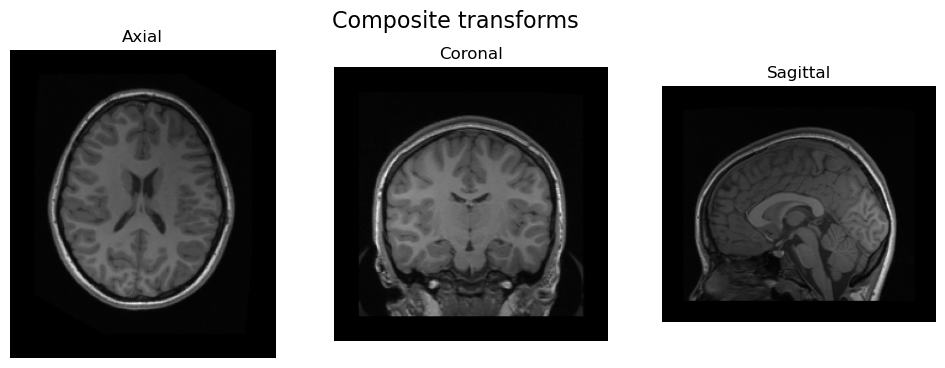

In [63]:
# Apply the transformation to the image
ImgT1_A = sitk.Resample(moving_image, transform)
imshow_orthogonal_view(ImgT1_A, title="Composite transforms")

## Noisy values

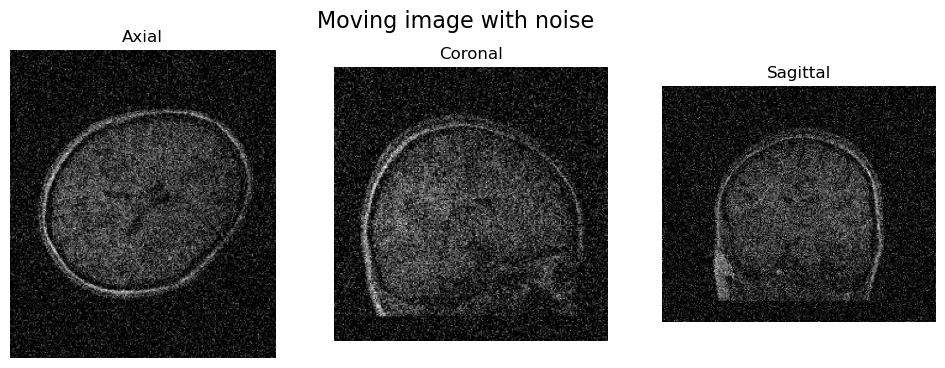

In [64]:
moving_image_noisy = sitk.AdditiveGaussianNoise(
    moving_image, mean=0, standardDeviation=200
)
imshow_orthogonal_view(moving_image_noisy, title="Moving image with noise")

Use the ImgT1.nii as the fixed image and ImgT1_240.nii as the moving image. Increase the noise level of the moving image and register it to the fixed image and repeat the registration at the same noise-level for different step length. For what standard deviation level and step length does the optimization algorithm cannot find the global minimum? Show the ortho-views of the noisy moving image.

Note: When the noise is added, the optimizer becomes more sensitive to the step length. We suggest to try, at least, standardDeviation=200, and step lengths = [10, 50, 150, 200].

By using the pyramidal multi-resolution registration strategy, we can make the registration of the noisy moving image to the fixed image more robust. Here we use the Gaussian pyramid procedure where we keep the image resolution (i.e., the shrink factor) in the different steps of the pyramid but introduce blurring by using a Gaussian filter at different levels. At the highest level most blurring is added, and we only see the coarse details in the image to be registered. Then, we go to finer and finer levels of details by reducing the blurring factor. The pyramidal procedure is implemented in the registration function and typically three levels are used and we just set the sigma = [3.0, 1.0, 0.0].

In [65]:
R.SetShrinkFactorsPerLevel(shrinkFactors=[2, 2, 2])
R.SetSmoothingSigmasPerLevel(smoothingSigmas=[3, 1, 0])
R.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

The pyramidal structure in image registration, often used in frameworks like ITK or SimpleITK, is a multi-resolution strategy designed to improve the efficiency, robustness, and accuracy of aligning images (e.g., a moving image to a fixed image). It leverages a coarse-to-fine approach by processing images at multiple scales, starting with low-resolution (coarse) versions and progressively refining the alignment at higher resolutions (finer details). 

1. What Is the Pyramid Structure?
The pyramid structure refers to a hierarchical representation of images at different resolution levels, typically created by:

Smoothing: Applying Gaussian blurring (controlled by a sigma parameter) to reduce noise and fine details.
Downsampling: Reducing the image size (e.g., by factors like 4, 2, 1) to create lower-resolution versions.
Each level of the pyramid corresponds to a version of the image:

Base (finest level): Full resolution, no smoothing (sigma=0.0, shrink factor=1).
Intermediate levels: Progressively lower resolution with increasing smoothing (e.g., sigma=1.0, shrink=2).
Top (coarsest level): Lowest resolution with the most smoothing (e.g., sigma=3.0 or 5.0, shrink=4).

3. How Does the Pyramid Work in Registration?
The registration process using a pyramid structure proceeds as follows:

Create the Pyramid:
Both the fixed and moving images are processed to create a pyramid of images at different resolutions.
Smoothing (Gaussian blur with sigma) reduces noise and details.
Downsampling (shrink factor) reduces image size.
Start at the Coarsest Level:
Register the heavily smoothed, downsampled images (e.g., sigma=3.0, shrink=4).
Use an optimizer (e.g., gradient descent) to compute the transformation (e.g., affine matrix) that aligns the moving image to the fixed image.
Because the images are low-resolution and smoothed, this step is fast and robust to noise.
Propagate and Refine:
The transformation from the coarse level is used as the initial guess for the next level (e.g., sigma=1.0, shrink=2).
The optimizer refines the transformation using images with more details and higher resolution.
This process repeats until the finest level (sigma=0.0, shrink=1), where the full-resolution images are aligned.
Output:
The final transformation (e.g., a 4x4 affine matrix) is applied to the moving image to produce the aligned image in the fixed image’s coordinate system.